# Predictive Maintenance: Binary and Multiclass Classification

This notebook performs exploratory data analysis, feature engineering, and trains advanced models for binary failure detection and multiclass failure type classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Loading and Initial Exploration

In [2]:
df=pd.read_csv("/Users/himeysankhe/JADS_PM_Notes/Intro ML lab/group_project/data/predictive_maintenance.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:
#Since UDI and Product ID are unique identifiers, they won't contribute to the predictive modeling. Hence, we can drop these columns.
df.drop(columns=['UDI', 'Product ID'], inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
 7   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(3), str(2)
memory usage: 735.4 KB


In [6]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


Getting numeric columns and categorical columns.

In [7]:
pmcol=df.columns.tolist()

In [8]:
pmcol

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [9]:
pmcolnum=[col for col in pmcol if df[col].dtype in ['int64', 'float64']]
pmcolcat=[col for col in pmcol if df[col].dtype == 'str']

In [10]:
pmcolnum

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target']

In [11]:
pmcolcat

['Type', 'Failure Type']

## Exploratory Data Analysis (EDA)

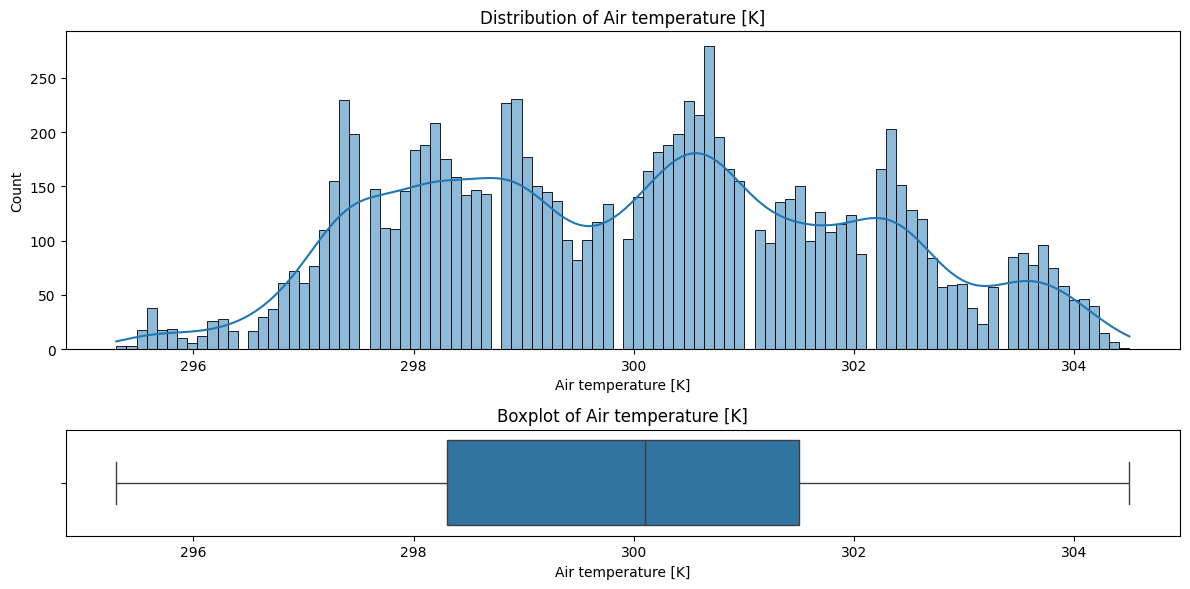

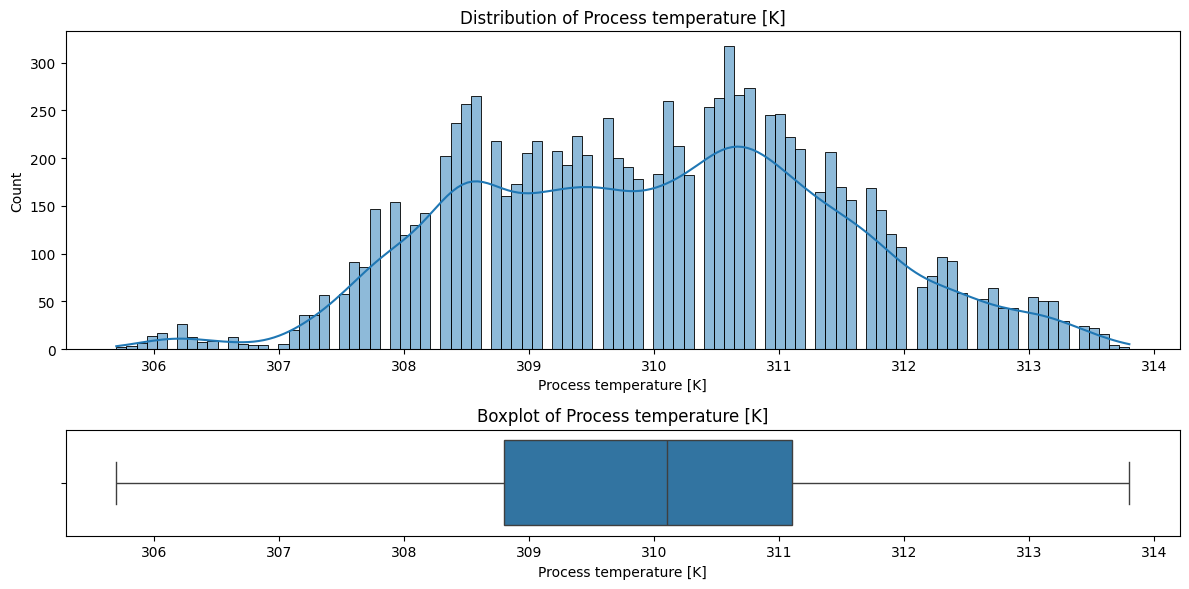

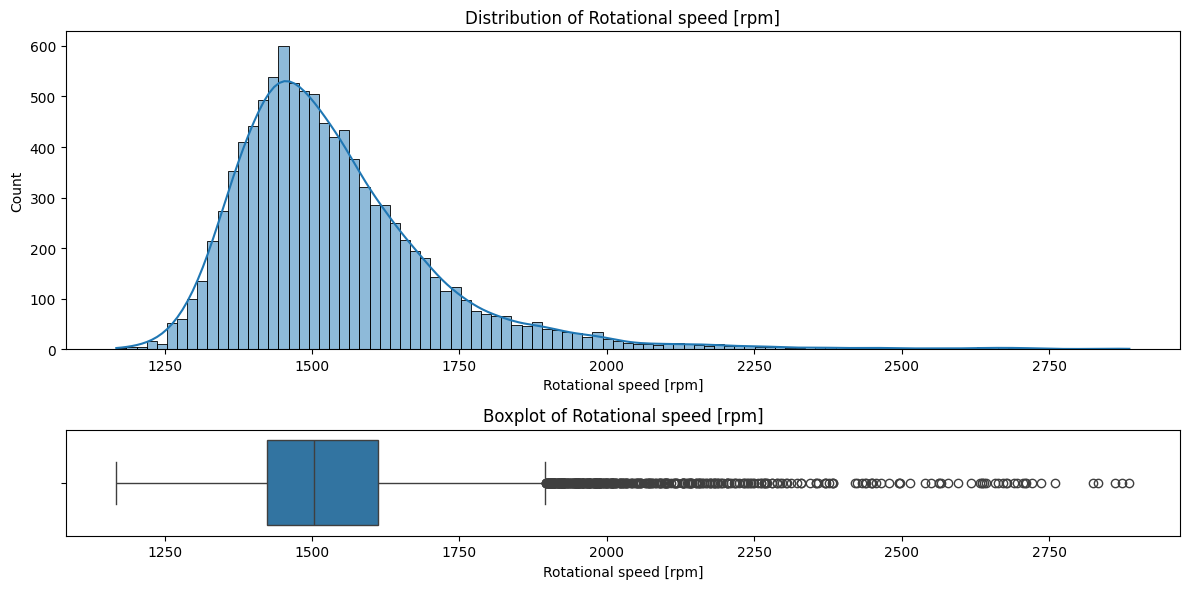

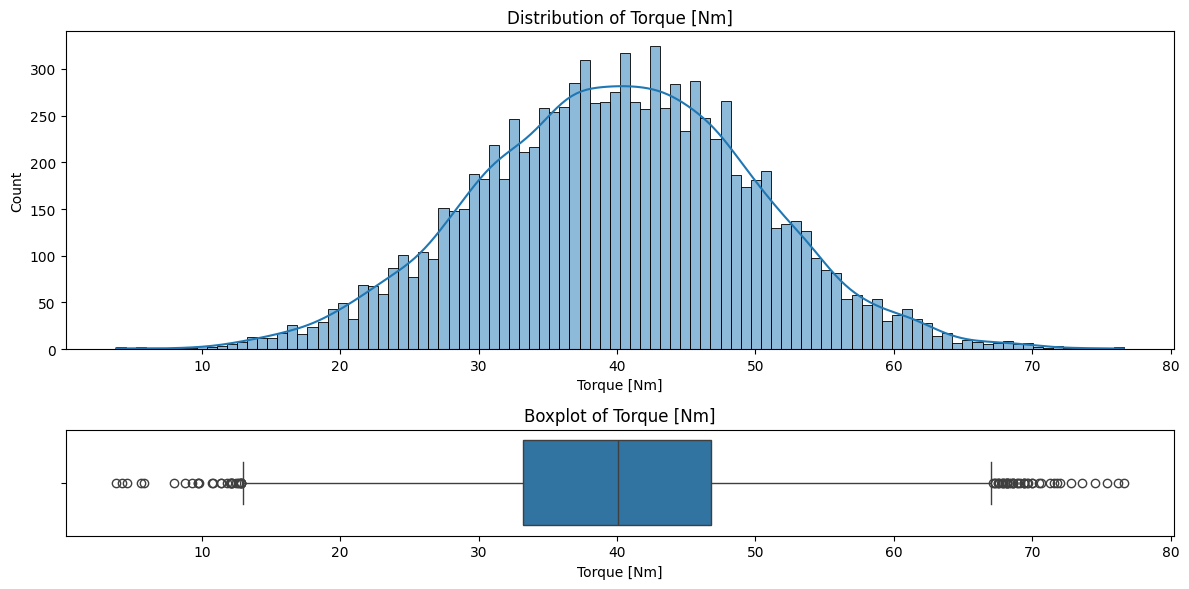

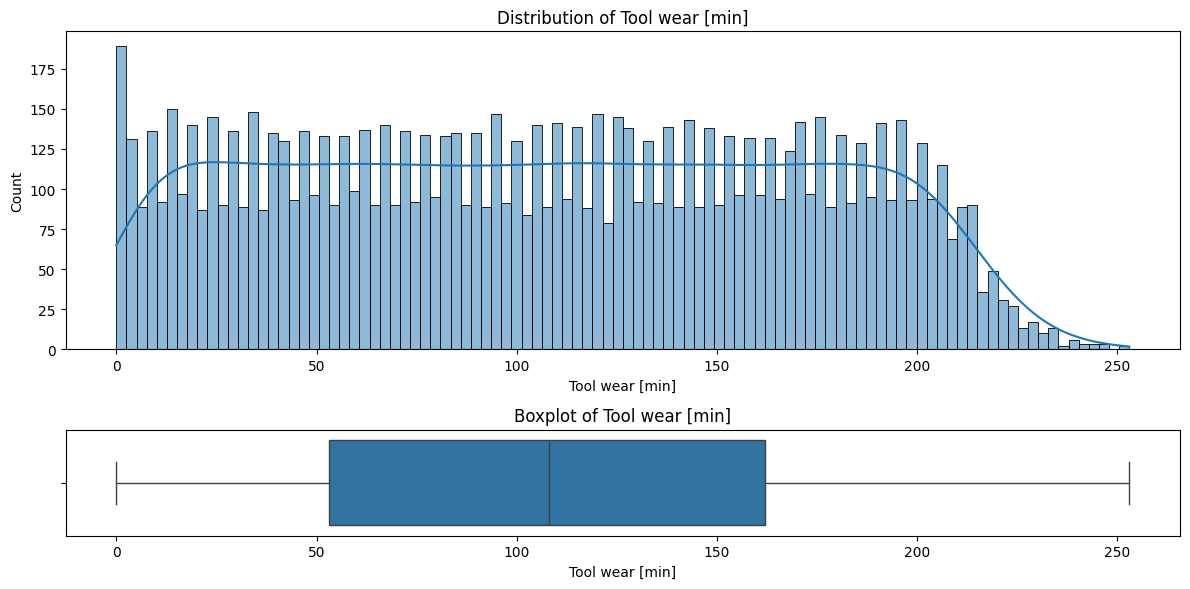

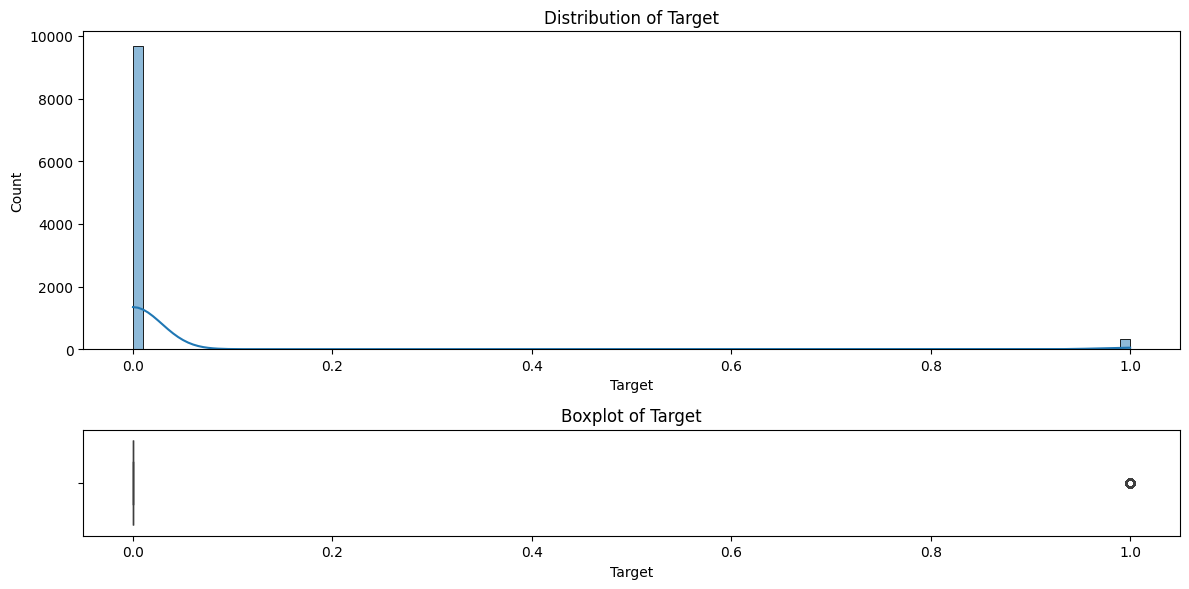

In [12]:
for col in pmcolnum:
    fig, axes = plt.subplots(
        2, 1, 
        figsize=(12, 6), 
        gridspec_kw={'height_ratios': [3, 1]}  # histogram bigger than boxplot
    )

    # Histogram + KDE (Top)
    sns.histplot(df[col], kde=True, bins=100, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot (Bottom)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


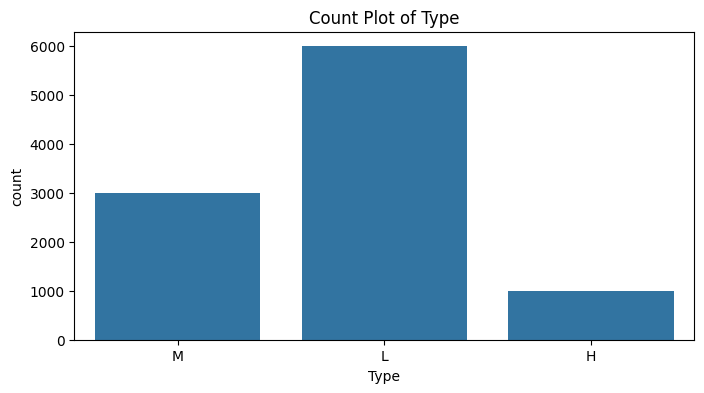

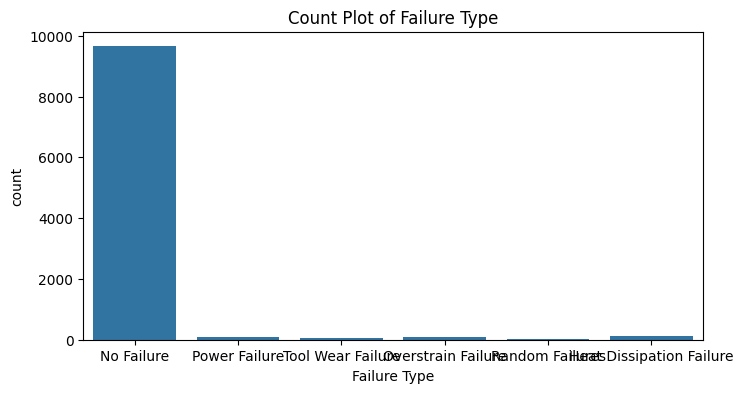

In [13]:
for col in pmcolcat:
    print(df[col].value_counts()) 
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')

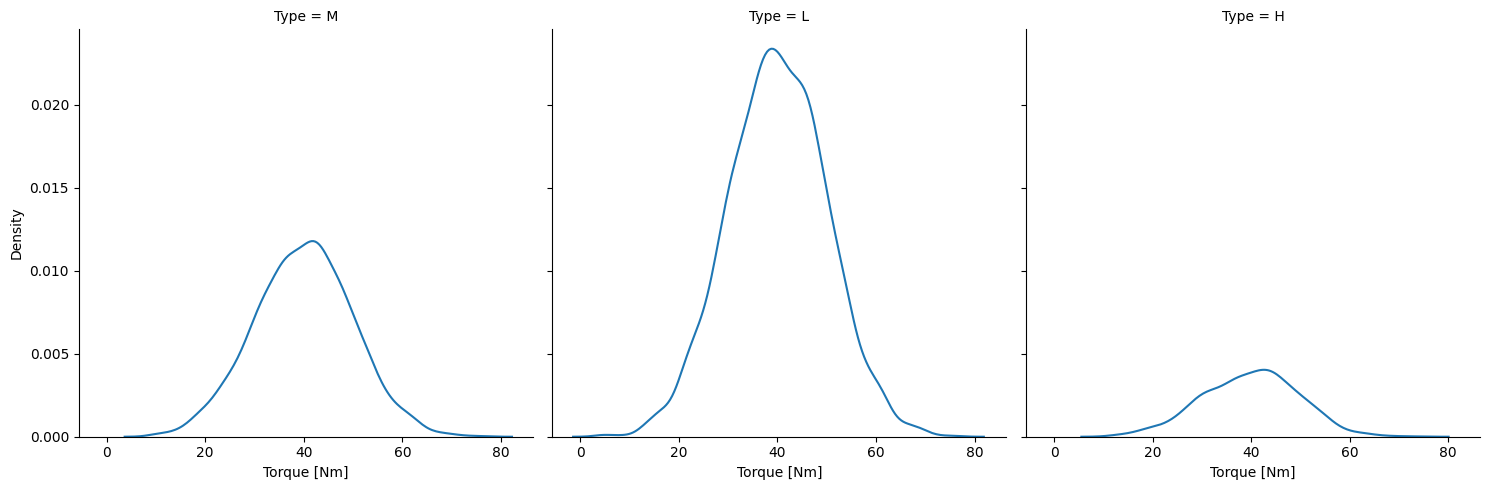

In [14]:
sns.displot(data=df, x="Torque [Nm]", col="Type", kind="kde");

In [15]:
from sklearn.preprocessing import OneHotEncoder

One hot encoding for types:

In [16]:
encoder=OneHotEncoder(sparse_output=False, drop='first')  
type_encoded=encoder.fit_transform(df[['Type']])
type_encoded_df=pd.DataFrame(type_encoded, columns=encoder.get_feature_names_out(['Type']))
df=pd.concat([df, type_encoded_df], axis=1)
df.drop(columns=['Type'], inplace=True)
df

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,No Failure,0.0,1.0
1,298.2,308.7,1408,46.3,3,0,No Failure,1.0,0.0
2,298.1,308.5,1498,49.4,5,0,No Failure,1.0,0.0
3,298.2,308.6,1433,39.5,7,0,No Failure,1.0,0.0
4,298.2,308.7,1408,40.0,9,0,No Failure,1.0,0.0
...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,No Failure,0.0,1.0
9996,298.9,308.4,1632,31.8,17,0,No Failure,0.0,0.0
9997,299.0,308.6,1645,33.4,22,0,No Failure,0.0,1.0
9998,299.0,308.7,1408,48.5,25,0,No Failure,0.0,0.0


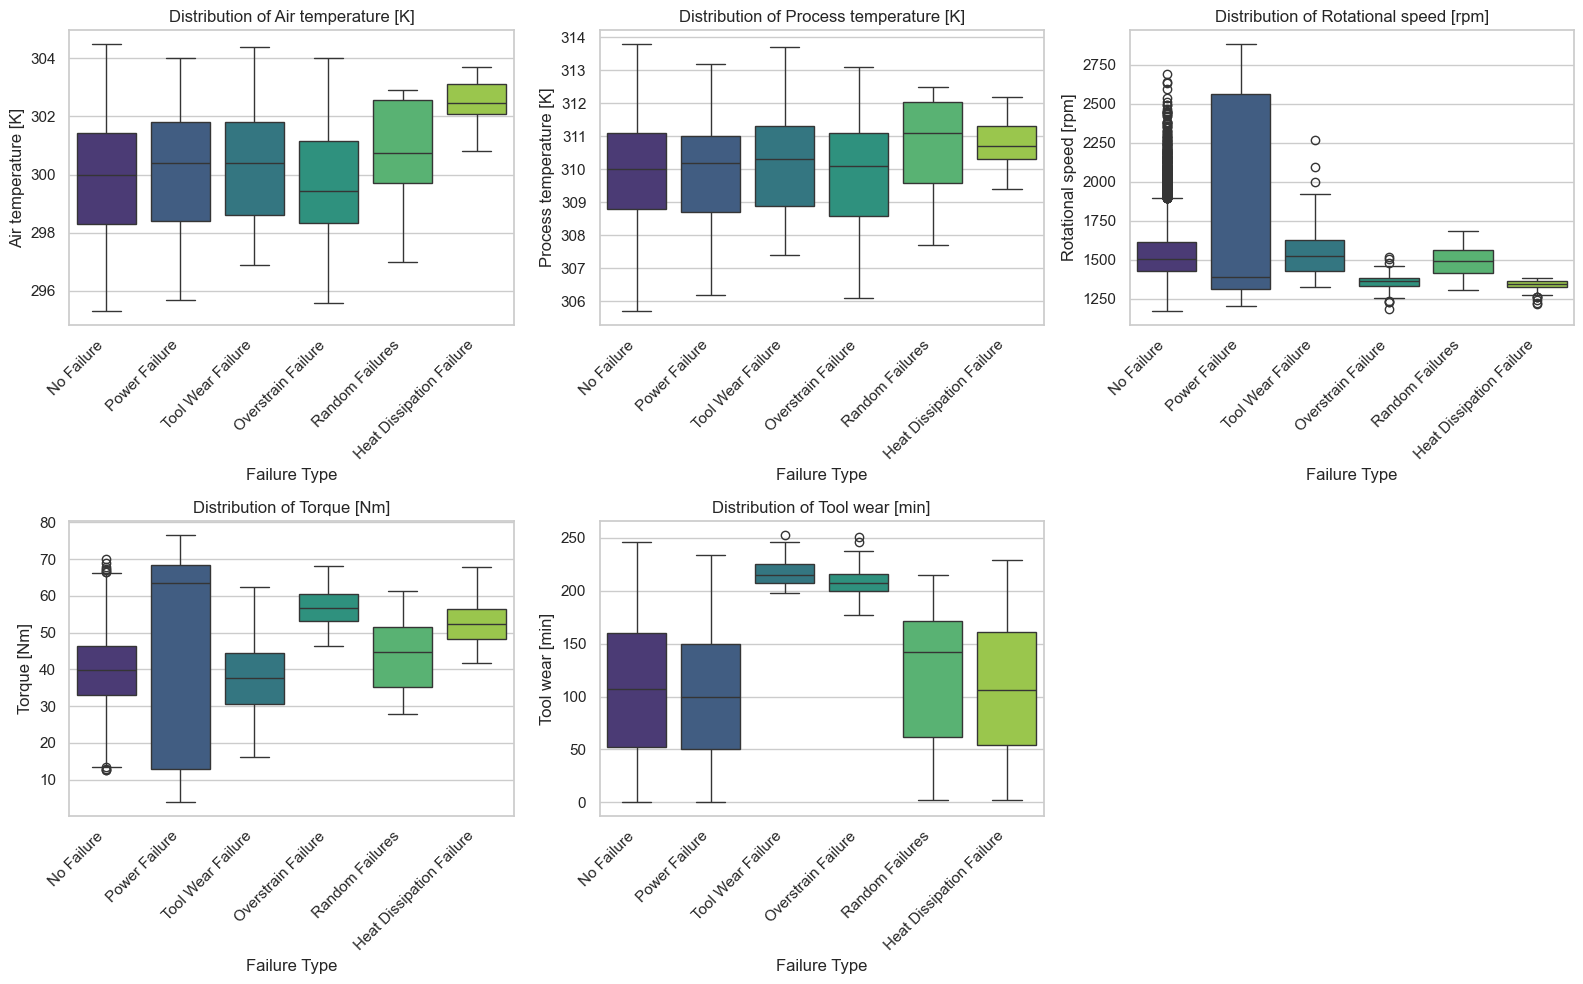

In [17]:
sensors = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]


plt.figure(figsize=(16, 10))
sns.set_theme(style="whitegrid")

for i, sensor in enumerate(sensors, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='Failure Type', y=sensor, palette='viridis')
    plt.title(f'Distribution of {sensor}', fontsize=12)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
X = df.drop(columns=['Target', 'Failure Type'])
y_bin = df['Target']       # Binary: 0 or 1
y_multi = df['Failure Type'] # Multiclass: 'No Failure', 'Power Failure', etc.

# Stratified Split using the Multiclass label
# Stratifying on y_multi because it ensures that even the rarest failure types are represented in both train and test sets.
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)
print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")
print(f"Failure ratio in Training: {y_train_bin.mean():.2%}")
print(f"Failure ratio in Testing: {y_test_bin.mean():.2%}")

Training set: 8000 rows
Testing set: 2000 rows
Failure ratio in Training: 3.41%
Failure ratio in Testing: 3.30%


## Feature Engineering

In [ ]:
for data in [X_train, X_test]:
    data['Temp_Diff'] = data['Process temperature [K]'] - data['Air temperature [K]']
    data['Power'] = data['Torque [Nm]'] * data['Rotational speed [rpm]']
    data['Wear_Strain'] = data['Tool wear [min]'] * data['Torque [Nm]']

In [23]:
X_train.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M,Temp_Diff,Power,Wear_Strain
7755,300.4,311.8,1362,47.6,188,0.0,1.0,11.4,64831.2,8948.8
2671,299.7,309.3,1399,41.9,221,0.0,1.0,9.6,58618.1,9259.9
4377,301.8,309.6,1436,49.0,214,0.0,1.0,7.8,70364.0,10486.0
3137,300.4,309.9,1567,36.5,72,1.0,0.0,9.5,57195.5,2628.0
1935,298.1,307.9,1377,55.1,42,0.0,1.0,9.8,75872.7,2314.2


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[ 0.19728408,  1.21218478, -0.97842652, ...,  1.40207265,
         0.47300552,  1.64036788],
       [-0.15275421, -0.47587151, -0.77231753, ..., -0.39967522,
        -0.13749063,  1.75054779],
       [ 0.89736065, -0.27330475, -0.56620854, ..., -2.2014231 ,
         1.01665573,  2.18478623],
       ...,
       [-0.35277609, -0.88100502, -0.29882391, ..., -0.59986943,
         0.00831666,  1.52622136],
       [ 0.39730596,  1.14466253,  0.22480433, ...,  0.90158713,
        -1.02859628,  0.90647268],
       [-2.20297846, -2.5690613 , -1.52990732, ...,  0.60129582,
         1.77221239, -0.93800478]], shape=(8000, 10))

In [26]:
#we will keep it in array format for modeling as it is faster to train models on arrays than dataframes.

Correlation Matrix

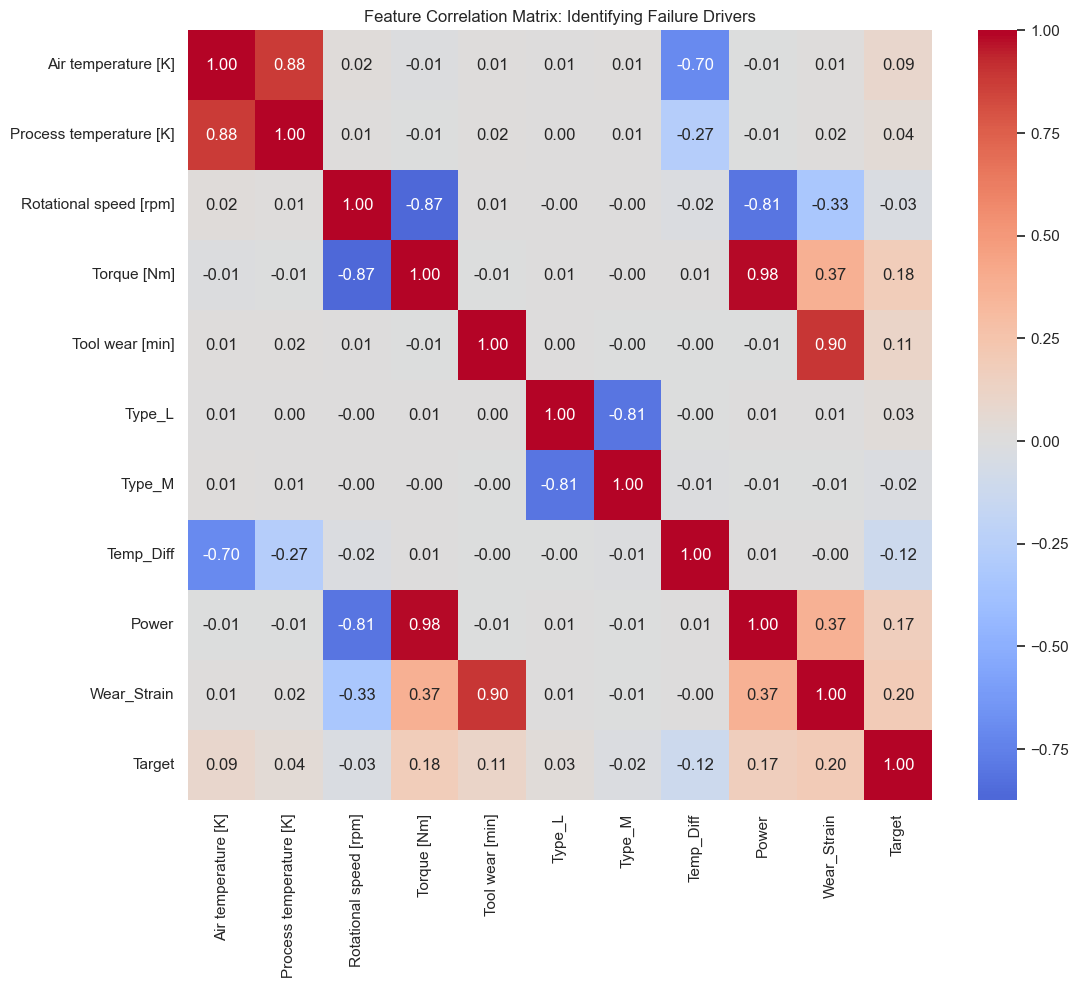

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

train_data_corr = X_train.copy()
train_data_corr['Target'] = y_train_bin.copy()

corr_matrix = train_data_corr.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix: Identifying Failure Drivers')
plt.show()

## Model Development

In [31]:
X_train

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M,Temp_Diff,Power,Wear_Strain
7755,300.4,311.8,1362,47.6,188,0.0,1.0,11.4,64831.2,8948.8
2671,299.7,309.3,1399,41.9,221,0.0,1.0,9.6,58618.1,9259.9
4377,301.8,309.6,1436,49.0,214,0.0,1.0,7.8,70364.0,10486.0
3137,300.4,309.9,1567,36.5,72,1.0,0.0,9.5,57195.5,2628.0
1935,298.1,307.9,1377,55.1,42,0.0,1.0,9.8,75872.7,2314.2
...,...,...,...,...,...,...,...,...,...,...
3088,300.0,309.1,1624,30.8,155,0.0,1.0,9.1,50019.2,4774.0
2069,299.7,309.6,1553,41.0,179,0.0,0.0,9.9,63673.0,7339.0
2329,299.3,308.7,1484,40.5,213,1.0,0.0,9.4,60102.0,8626.5
7937,300.8,311.7,1578,31.4,219,1.0,0.0,10.9,49549.2,6876.6


### Binary Classification

#### XGBoost Model

In [ ]:
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

X_train_numeric = X_train_numeric.drop(columns=['Target'], errors='ignore')
X_test_numeric = X_test_numeric.drop(columns=['Target'], errors='ignore')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

X_train_scaled = np.ascontiguousarray(X_train_scaled)
X_test_scaled = np.ascontiguousarray(X_test_scaled)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Calculate the ideal weight
# Formula: count(negative) / count(positive)
# In this dataset, this is roughly 9665 / 335 ≈ 28.8
# We'll use 25 as a slightly more conservative starting point.

xgb_cost_sensitive = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=25, 
    objective='binary:logistic',
    random_state=42
)

xgb_cost_sensitive.fit(X_train_scaled, y_train_bin)


y_pred = xgb_cost_sensitive.predict(X_test_scaled)

print("XGBoost (Cost-Sensitive, No Resampling) Results:")
print(classification_report(y_test_bin, y_pred))

XGBoost (Cost-Sensitive, No Resampling) Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1934
           1       0.61      0.86      0.72        66

    accuracy                           0.98      2000
   macro avg       0.80      0.92      0.85      2000
weighted avg       0.98      0.98      0.98      2000



In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [20, 25, 30] # Tuning the balancing act
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(objective='binary:logistic', random_state=42),
    param_distributions=param_grid,
    n_iter=10, 
    scoring='f1', # Optimizing for the balance of Precision and Recall
    cv=3
)

xgb_search.fit(X_train_scaled, y_train_bin)
best_xgb = xgb_search.best_estimator_

In [36]:
from sklearn.metrics import classification_report

# Use the best model found by the search
final_model = xgb_search.best_estimator_
y_pred_final = final_model.predict(X_test_scaled)

print("--- FINAL EVALUATION: TUNED XGBOOST FOR BINARY CLASSIFICATION ---")
print(classification_report(y_test_bin, y_pred_final))

--- FINAL EVALUATION: TUNED XGBOOST FOR BINARY CLASSIFICATION ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1934
           1       0.84      0.86      0.85        66

    accuracy                           0.99      2000
   macro avg       0.92      0.93      0.92      2000
weighted avg       0.99      0.99      0.99      2000



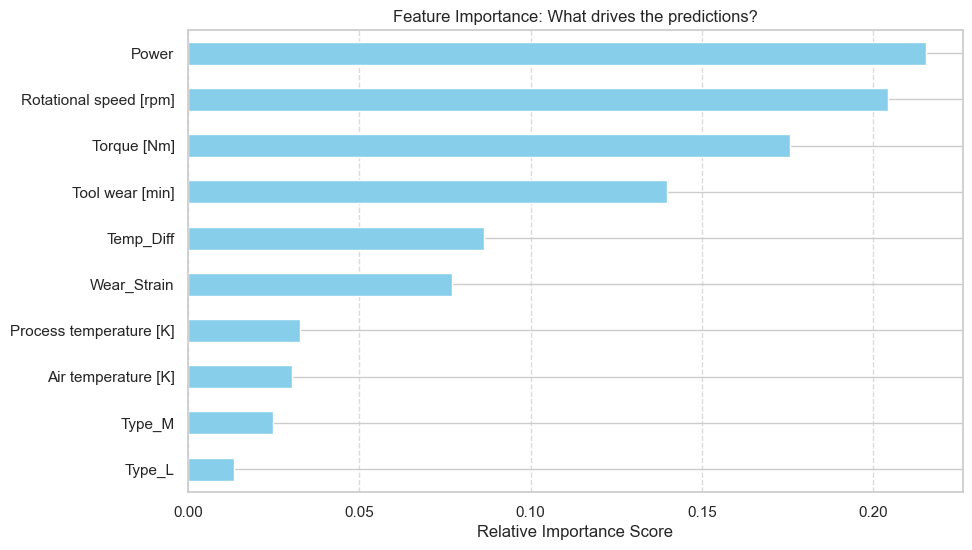

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importances = pd.Series(final_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Feature Importance: What drives the predictions?")
plt.xlabel("Relative Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(
    max_depth=5,            
    class_weight='balanced', 
    random_state=42
)


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,              
    random_state=42
)

# 3. Training
dt_model.fit(X_train_scaled, y_train_bin)
rf_model.fit(X_train_scaled, y_train_bin)

# 4. Evaluation
print("--- Decision Tree Results ---")
print(classification_report(y_test_bin, dt_model.predict(X_test_scaled)))

print("\n--- Random Forest Results ---")
print(classification_report(y_test_bin, rf_model.predict(X_test_scaled)))

--- Decision Tree Results ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1934
           1       0.38      0.83      0.52        66

    accuracy                           0.95      2000
   macro avg       0.69      0.89      0.75      2000
weighted avg       0.97      0.95      0.96      2000


--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1934
           1       0.91      0.80      0.85        66

    accuracy                           0.99      2000
   macro avg       0.95      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'] 
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=15,
    cv=3,
    scoring='f1', 
    n_jobs=-1
)

rf_random.fit(X_train_scaled, y_train_bin)
best_rf = rf_random.best_estimator_


In [42]:
# Get probabilities instead of hard 0/1 predictions
y_probs_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# Try a lower threshold to catch more failures
y_pred_adjusted = (y_probs_rf > 0.4).astype(int)

print("--- Adjusted Random Forest (Threshold 0.4) ---")
print(classification_report(y_test_bin, y_pred_adjusted))

--- Adjusted Random Forest (Threshold 0.4) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1934
           1       0.88      0.88      0.88        66

    accuracy                           0.99      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.99      0.99      0.99      2000



In [46]:
from sklearn.ensemble import VotingClassifier

# Use the 'soft' voting to average the probabilities
ensemble_model = VotingClassifier(
    estimators=[('xgb', best_xgb), ('rf', best_rf)],
    voting='soft'
)

ensemble_model.fit(X_train_scaled, y_train_bin)
# Check if the combined logic beats the individual scores

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb', ...), ('rf', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


In [47]:
from sklearn.ensemble import VotingClassifier

# 1. Define the Board of Directors
# We use your already-tuned versions of these models
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', best_xgb), # Your tuned XGBoost
        ('rf', best_rf)       # Your tuned Random Forest
    ],
    voting='soft' # Averages the probabilities
)

# 2. Train the Ensemble
ensemble_model.fit(X_train_scaled, y_train_bin)

# 3. Get Probabilities (to apply your 0.4 threshold)
y_probs_ensemble = ensemble_model.predict_proba(X_test_scaled)[:, 1]

# 4. Apply your winning 0.4 Threshold
y_pred_ensemble = (y_probs_ensemble > 0.4).astype(int)

# 5. Final Evaluation
print("--- ENSEMBLE (XGB + RF) Results ---")
print(classification_report(y_test_bin, y_pred_ensemble))

--- ENSEMBLE (XGB + RF) Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1934
           1       0.87      0.88      0.87        66

    accuracy                           0.99      2000
   macro avg       0.93      0.94      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [48]:
import joblib

# Save the individual tuned models
joblib.dump(best_xgb, 'best_xgb_binary.pkl')
joblib.dump(best_rf, 'best_rf_binary.pkl')

# Save the ensemble model
joblib.dump(ensemble_model, 'ensemble_binary_model.pkl')

# IMPORTANT: Also save your scaler! 
# You need the EXACT same scaling parameters to make predictions later.
joblib.dump(scaler, 'main_scaler.pkl')

print("Models and Scaler saved successfully!")

Models and Scaler saved successfully!
